This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [ ]:
!pip install keras keras-hub --upgrade -q

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Classification and regression

### Classifying movie reviews: A binary classification example

#### The IMDb dataset

In [1]:
import keras
keras.version()

'3.13.2'

In [2]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
train_data[0][:15]

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4]

In [13]:
train_labels[0]

np.int64(1)

In [14]:
max([max(sequence) for sequence in train_data])

9999

In [5]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]]
)
decoded_review[:100]

"? this film was just brilliant casting location scenery story direction everyone's really suited the"

#### Preparing the data

In [30]:
import numpy as np

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)
x_train.shape, x_train[0]

((8982, 10000), array([0., 1., 1., ..., 0., 0., 0.]))

array([0., 1., 1., ..., 0., 0., 0.])

In [8]:
y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")

#### Building your model

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential(
    [
        # Input(shape=(10000,)),
        Dense(16, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"), # бинарная классификация
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",         # бинарная классификация
    metrics=["accuracy"],
)

#### Validating your approach

In [38]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [21]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7301 - loss: 0.5827 - val_accuracy: 0.8491 - val_loss: 0.4480
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8933 - loss: 0.3479 - val_accuracy: 0.8851 - val_loss: 0.3209
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9246 - loss: 0.2371 - val_accuracy: 0.8898 - val_loss: 0.2819
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9441 - loss: 0.1757 - val_accuracy: 0.8877 - val_loss: 0.2745
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9597 - loss: 0.1334 - val_accuracy: 0.8857 - val_loss: 0.2848
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9723 - loss: 0.1032 - val_accuracy: 0.8849 - val_loss: 0.3008
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9804 - loss: 0.0805 - val_accuracy: 0.8817 - val_loss: 0.3237
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9874 - loss: 0.0616 - val_accuracy: 0.8797 - v

In [ ]:
# history = model.fit(
#     x_train,
#     y_train,
#     epochs=20,
#     batch_size=512,
#     validation_split=0.2,
# )

In [15]:
# history_dict = history.history
# history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

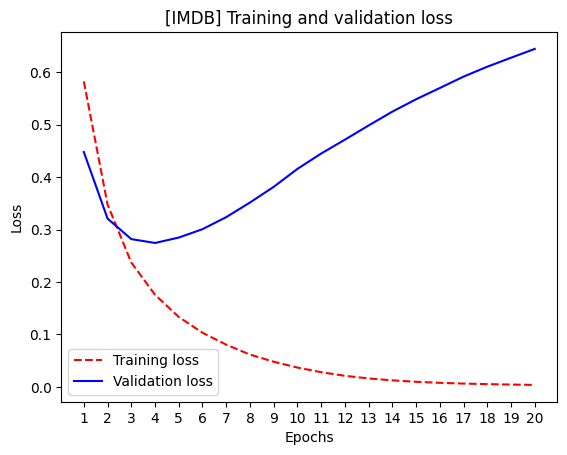

In [22]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

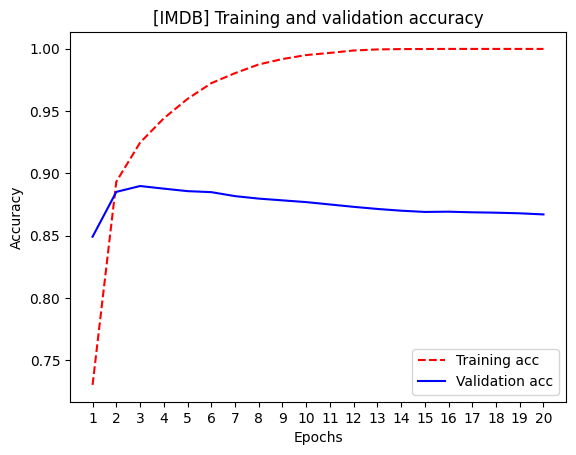

In [23]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

In [ ]:
results

#### Using a trained model to generate predictions on new data

In [24]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.00550594],
       [0.99999934],
       [0.677242  ],
       ...,
       [0.00104477],
       [0.00675541],
       [0.88898677]], dtype=float32)

#### Further experiments

#### Wrapping up

### Classifying newswires: A multiclass classification example

#### The Reuters dataset

In [39]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
    num_words=10000
)

In [27]:
train_data.shape

(8982,)

In [ ]:
len(test_data)

In [ ]:
train_data[10]

In [28]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[10]]
)
train_labels[10]

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


np.int64(3)

#### Preparing the data

In [40]:
x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)
x_train.shape, x_train[0]

((8982, 10000), array([0., 1., 1., ..., 0., 0., 0.]))

In [34]:
# def one_hot_encode(labels, num_classes=46):
#     results = np.zeros((len(labels), num_classes))
#     for i, label in enumerate(labels):
#         results[i, label] = 1.0
#     return results

# y_train = one_hot_encode(train_labels)
# y_test = one_hot_encode(test_labels)

In [41]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)
train_labels[0], y_train[0]

(np.int64(3),
 array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

#### Building your model

In [46]:
model = Sequential(
    [
        Dense(64, activation="relu"),
        Dense(64, activation="relu"),
        Dense(46, activation="softmax"), # многоклассовая классификация
    ]
)
from tensorflow.keras.metrics import TopKCategoricalAccuracy
top_3_accuracy = TopKCategoricalAccuracy(k=3,
                                         name="top_3_accuracy"
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",    # многоклассовая классификация
    metrics=["accuracy", top_3_accuracy],
)

#### Validating your approach

In [47]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [48]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.3698 - loss: 3.1871 - top_3_accuracy: 0.5932 - val_accuracy: 0.5270 - val_loss: 2.3705 - val_top_3_accuracy: 0.6690
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6215 - loss: 1.8666 - top_3_accuracy: 0.7343 - val_accuracy: 0.6620 - val_loss: 1.5608 - val_top_3_accuracy: 0.7700
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.7200 - loss: 1.3157 - top_3_accuracy: 0.8156 - val_accuracy: 0.7180 - val_loss: 1.2775 - val_top_3_accuracy: 0.8130
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7806 - loss: 1.0364 - top_3_accuracy: 0.8652 - val_accuracy: 0.7560 - val_loss: 1.1367 - val_top_3_accuracy: 0.8500
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8256 - loss: 0.8238 - top_3_accuracy: 0.9063 - val_accuracy: 0.7840 - val_loss: 1.0424 - val_top_3_accuracy: 0.8760
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8619 - loss: 0.6532 - top_3_ac

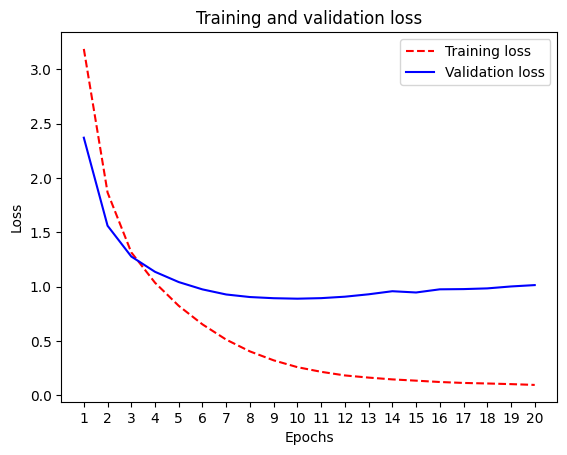

In [49]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

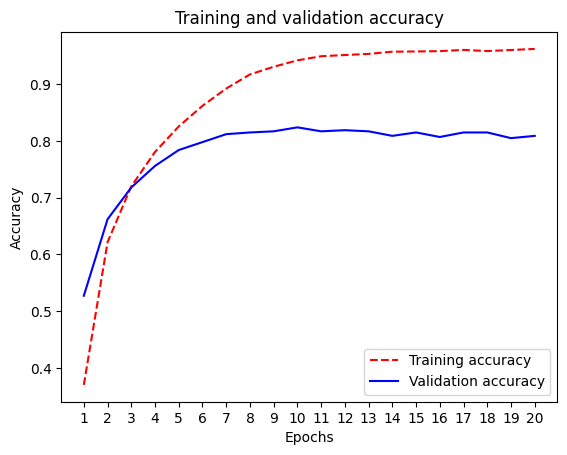

In [50]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

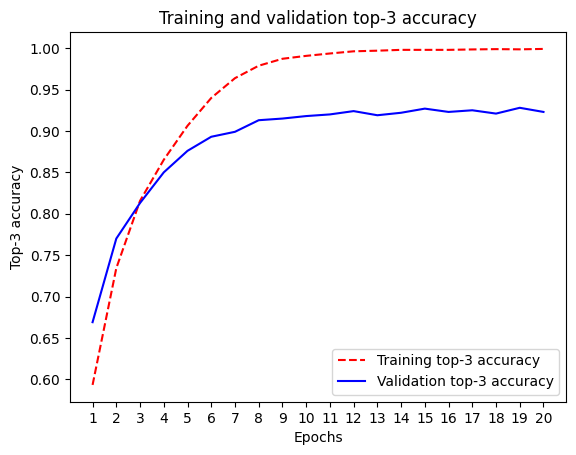

In [51]:
plt.clf()
acc = history.history["top_3_accuracy"]
val_acc = history.history["val_top_3_accuracy"]
plt.plot(epochs, acc, "r--", label="Training top-3 accuracy")
plt.plot(epochs, val_acc, "b", label="Validation top-3 accuracy")
plt.title("Training and validation top-3 accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Top-3 accuracy")
plt.legend()
plt.show()

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    x_train,
    y_train,
    epochs=9,
    batch_size=512,
)
results = model.evaluate(x_test, y_test)

In [ ]:
results

In [ ]:
import copy
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels == test_labels_copy)
hits_array.mean()

#### Generating predictions on new data

In [ ]:
predictions = model.predict(x_test)

In [ ]:
predictions[0].shape

In [ ]:
np.sum(predictions[0])

In [ ]:
np.argmax(predictions[0])

#### A different way to handle the labels and the loss

In [ ]:
y_train = train_labels
y_test = test_labels

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

#### The importance of having sufficiently large intermediate layers

In [ ]:
model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(46, activation="softmax"),
    ]
)
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val),
)

#### Further experiments

#### Wrapping up

### Predicting house prices: A regression example

#### The California Housing Price dataset

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from keras.datasets import california_housing

(train_data, train_targets), (test_data, test_targets) = (
    california_housing.load_data(version="small")
)

In [2]:
import pandas as pd
df = pd.DataFrame(data=train_data)
df.head()

,0,1,2,3,4,5,6,7
0,-122.239998,37.730000,21.0,7031.0,1249.0,2930.0,1235.0,4.5213
1,-122.279999,37.849998,48.0,2063.0,484.0,1054.0,466.0,2.2625
2,-122.290001,37.820000,2.0,158.0,43.0,94.0,57.0,2.5625
3,-122.290001,37.810001,46.0,935.0,297.0,582.0,277.0,0.7286
4,-122.180000,37.759998,37.0,1575.0,358.0,933.0,320.0,2.2917


In [ ]:
train_data.shape

In [ ]:
test_data.shape

In [ ]:
train_targets

#### Preparing the data

In [3]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
x_train = (train_data - mean) / std
x_test = (test_data - mean) / std
# Обратите внимание, что величины, используемые для нормализации контрольных данных,
# вычисляются с использованием обучающих данных. Никогда не следует использовать в
# работе какие-либо значения, вычисленные по контрольным данным, даже для таких простых шагов,
# как нормализация.


In [4]:
y_train = train_targets / 100000
y_test = test_targets / 100000

In [5]:
df = pd.DataFrame(data=x_train)
df.head()

,0,1,2,3,4,5,6,7
0,-0.176150,-1.594003,-2.424078,3.423944,2.589801,2.918909,2.800940,0.501960
1,-0.957497,0.888302,0.369453,0.058881,0.194700,0.089491,0.228324,-0.637887
2,-1.152871,0.267745,-4.389895,-1.231466,-1.186006,-1.358399,-1.139946,-0.486500
3,-1.152871,0.060919,0.162525,-0.705167,-0.390769,-0.622388,-0.403958,-1.411932
4,0.995797,-0.973447,-0.768652,-0.271664,-0.199787,-0.093004,-0.260105,-0.623152


#### Building your model

In [7]:
def get_model():
        # Модель заканчивается одномерным слоем, не имеющим функции активации (это линейный слой).
        # Это типичная конфигурация для скалярной регрессии (целью которой является предсказание
        # одного значения на непрерывной числовой прямой).
        # Применение функции активации могло бы ограничить диапазон выходных значений;
        # например, если в последнем слое применить функцию активации sigmoid,
        # модель обучилась бы предсказывать только значения из диапазона между 0 и 1.
        # В данном случае, с линейным последним слоем, модель способна предсказывать
        # значения из любого диапазона.
    model = Sequential(
        [
            Dense(64, activation="relu"),
            Dense(64, activation="relu"),
            Dense(1),
        ]
    )
    # Обратите внимание, что модель компилируется с функцией потерь mse — mean squared error (среднеквадратичная ошибка),
    # вычисляющей квадрат разности между предсказанными и целевыми значениями. Эта функция широко используется в задачах регрессии.
    # Мы также включили новый параметр в мониторинг на этапе обучения: mae — mean absolute error (средняя абсолютная ошибка).
    # Это абсолютное значение разности между предсказанными и целевыми значениями. Например, значение MAE, равное 0,5,
    # в нашей задаче означает, что в среднем прогнозы отклоняются на 500 долларов США.
    # Понятие точности неприменимо для регрессии, поэтому для оценки качества часто берется средняя абсолютная ошибка (mean absolute error, MAE).
    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mean_absolute_error"],
    )
    return model


#### Validating your approach using K-fold validation

In [11]:
import numpy as np

k = 4
num_val_samples = len(x_train) // k
num_epochs = 50
all_scores = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    model.fit(
        fold_x_train,
        fold_y_train,
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    scores = model.evaluate(fold_x_val, fold_y_val, verbose=0)
    val_loss, val_mae = scores
    all_scores.append(val_mae)

Processing fold #1
Processing fold #2
Processing fold #3
Processing fold #4


In [ ]:
[round(value, 3) for value in all_scores]

In [ ]:
round(np.mean(all_scores), 3)

In [ ]:
k = 4
num_val_samples = len(x_train) // k
num_epochs = 200
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i + 1}")
    fold_x_val = x_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_y_val = y_train[i * num_val_samples : (i + 1) * num_val_samples]
    fold_x_train = np.concatenate(
        [x_train[: i * num_val_samples], x_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    fold_y_train = np.concatenate(
        [y_train[: i * num_val_samples], y_train[(i + 1) * num_val_samples :]],
        axis=0,
    )
    model = get_model()
    history = model.fit(
        fold_x_train,
        fold_y_train,
        validation_data=(fold_x_val, fold_y_val),
        epochs=num_epochs,
        batch_size=16,
        verbose=0,
    )
    mae_history = history.history["val_mean_absolute_error"]
    all_mae_histories.append(mae_history)

In [ ]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

In [ ]:
epochs = range(1, len(average_mae_history) + 1)
plt.plot(epochs, average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [ ]:
truncated_mae_history = average_mae_history[10:]
epochs = range(10, len(truncated_mae_history) + 10)
plt.plot(epochs, truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

In [ ]:
model = get_model()
model.fit(x_train, y_train, epochs=130, batch_size=16, verbose=0)
test_mean_squared_error, test_mean_absolute_error = model.evaluate(
    x_test, y_test
)

In [ ]:
round(test_mean_absolute_error, 3)

#### Generating predictions on new data

In [ ]:
predictions = model.predict(x_test)
predictions[0]

#### Wrapping up